# 1. 라이브러리 로드

In [10]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.subplots as sp

# 한글 폰트 설정 (Windows: 'Malgun Gothic', MacOS: 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

from datetime import datetime

from tqdm import tqdm

import sys
sys.path.append('C:/lucio 서강대 정보통신대학원/학위논문/아파트 거래량 이상탐지/apt_volume_anomaly_detection/dataset')

import warnings
warnings.filterwarnings('ignore')

# 2. 데이터 로드

In [2]:
apt_volume_path = 'C:/lucio 서강대 정보통신대학원/학위논문/아파트 거래량 이상탐지/apt_volume_anomaly_detection/dataset/apt_volume/apt_purchase_volume_'

# 초기값 설정
start_year, start_month = 2010, 6
end_year, end_month = 2024, 6

# 1년 단위 파일명 리스트 컴프리헨션 생성
date_index_lst = [
    f"{year:04}{start_month:02}_{year+1:04}{start_month-1:02}"
    for year in range(start_year, end_year)
]

# 마지막 파일 추가 (202406_202412)
date_index_lst.append("202406_202412")

In [5]:
# 행정구 / 월 단위 데이터셋 생성
# monthly_apt_volume_df_lst = []
# for date_index in tqdm(date_index_lst):

#     origin_apt_volume_df = pd.read_excel(f'C:/lucio 서강대 정보통신대학원/학위논문/아파트 거래량 이상탐지/apt_volume_anomaly_detection/dataset/apt_volume/apt_purchase_volume_{date_index}.xlsx', header=12)

#     origin_apt_volume_df['region'] = origin_apt_volume_df['시군구'].map(lambda x: ' '.join(x.split(' ')[:2]))
#     origin_apt_volume_df['거래금액(만원)'] = origin_apt_volume_df['거래금액(만원)'].map(lambda x: int(x.replace(',', '')) * 10000)

#     single_monthly_apt_volume_df = origin_apt_volume_df.groupby(['region', '계약년월']).agg(
#                                                                                             volume_cnt=('NO', 'nunique'),
#                                                                                             avg_area_size=('전용면적(㎡)', 'mean'),
#                                                                                             avg_sales=('거래금액(만원)', 'mean'),
#                                                                                             avg_floor_cnt=('층', 'mean')
#                                                                                         ).reset_index().rename(columns={'계약년월' : 'month'})

#     monthly_apt_volume_df_lst.append(single_monthly_apt_volume_df)


# monthly_apt_volume_df = pd.concat(monthly_apt_volume_df_lst, ignore_index=True)

monthly_apt_volume_df = pd.read_excel('C:/lucio 서강대 정보통신대학원/학위논문/아파트 거래량 이상탐지/apt_volume_anomaly_detection/dataset/apt_volume/apt_purchase_volume_monthly.xlsx', index_col=0)
monthly_apt_volume_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4375 entries, 0 to 4374
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   region         4375 non-null   object        
 1   month          4375 non-null   int64         
 2   volume_cnt     4375 non-null   int64         
 3   avg_area_size  4375 non-null   float64       
 4   avg_sales      4375 non-null   float64       
 5   avg_floor_cnt  4375 non-null   float64       
 6   date           4375 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(1)
memory usage: 273.4+ KB


In [45]:
# data type 변경
monthly_apt_volume_df['date'] = pd.to_datetime(monthly_apt_volume_df['month'].astype(str), format='%Y%m')

In [6]:
monthly_apt_volume_df

,region,month,volume_cnt,avg_area_size,avg_sales,avg_floor_cnt,date
0,서울특별시 강남구,201006,180,72.872581,7.497848e+08,9.033333,2010-06-01
1,서울특별시 강남구,201007,176,74.752961,7.591279e+08,8.482955,2010-07-01
2,서울특별시 강남구,201008,203,79.500165,8.385077e+08,7.758621,2010-08-01
3,서울특별시 강남구,201009,223,73.994781,7.879408e+08,7.896861,2010-09-01
4,서울특별시 강남구,201010,425,80.109369,8.605932e+08,8.214118,2010-10-01
...,...,...,...,...,...,...,...
4370,서울특별시 중랑구,202408,201,70.899098,6.694378e+08,10.174129,2024-08-01
4371,서울특별시 중랑구,202409,96,69.455530,6.258438e+08,9.562500,2024-09-01
4372,서울특별시 중랑구,202410,115,69.629382,6.276126e+08,9.800000,2024-10-01
4373,서울특별시 중랑구,202411,90,68.257834,6.161556e+08,9.488889,2024-11-01


# 3. EDA

## 3.1 행정구 / 월 단위 거래량 시각화

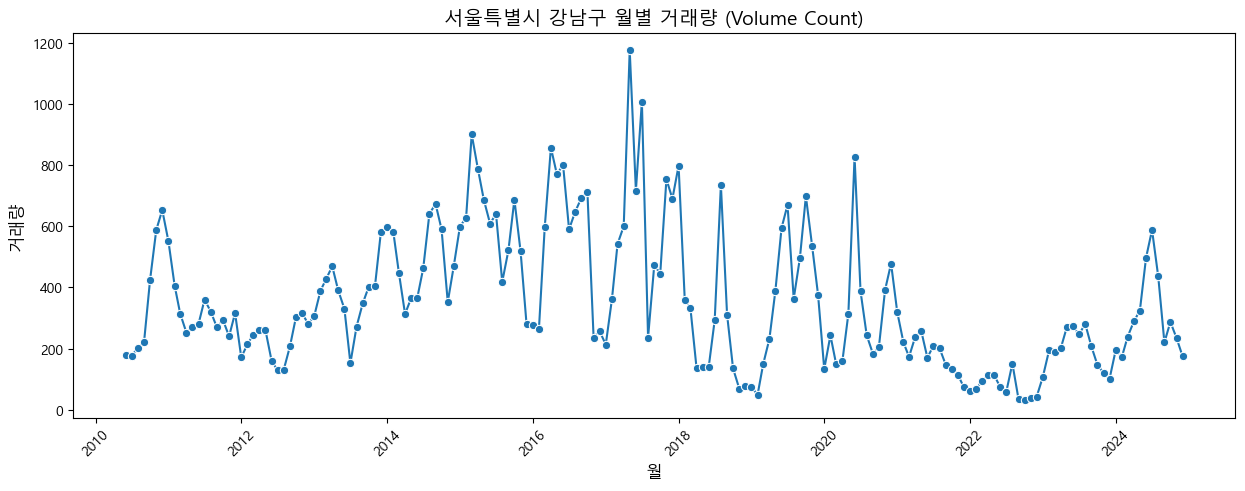

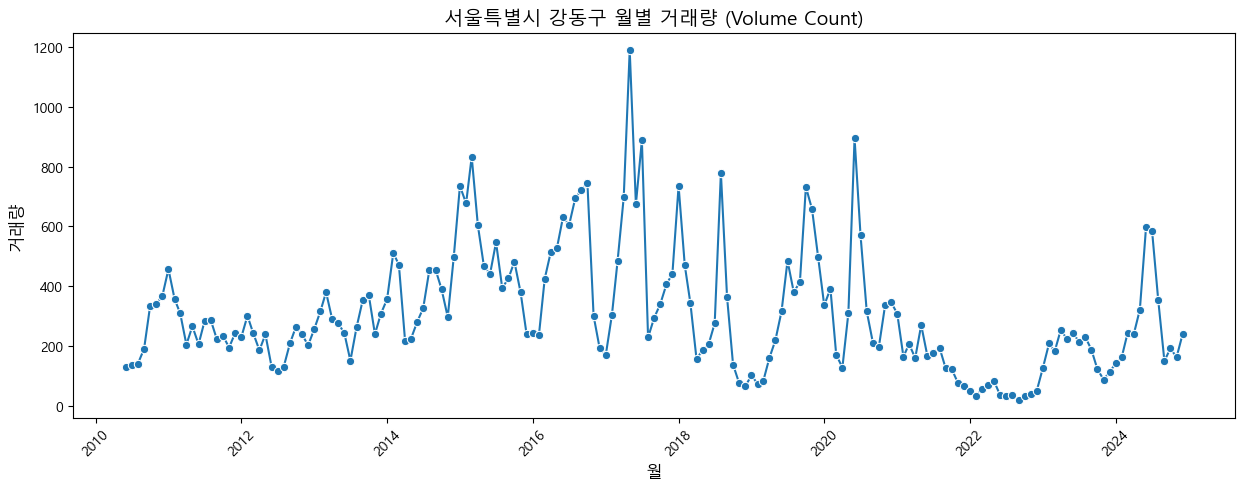

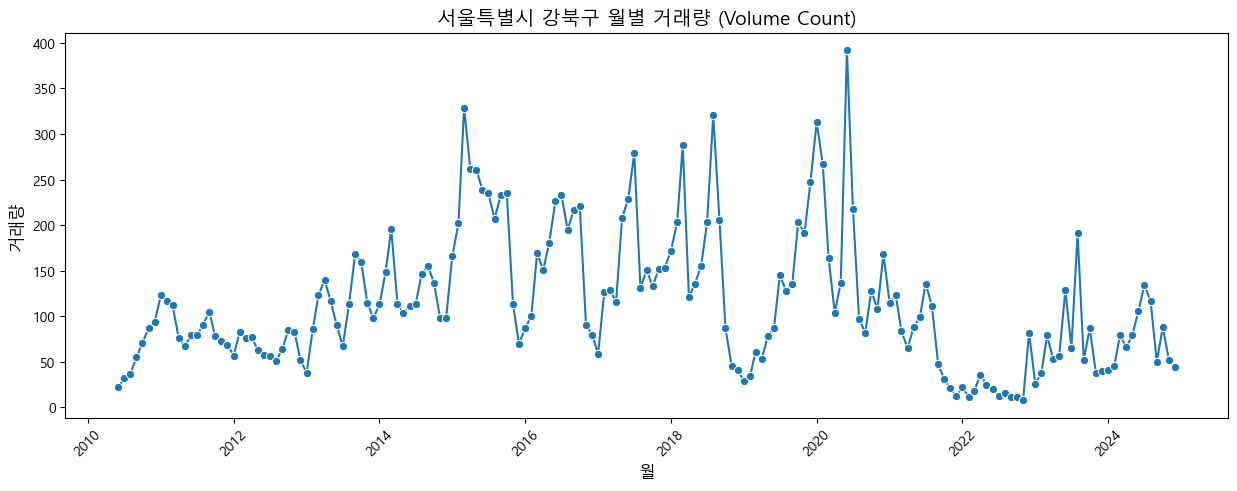

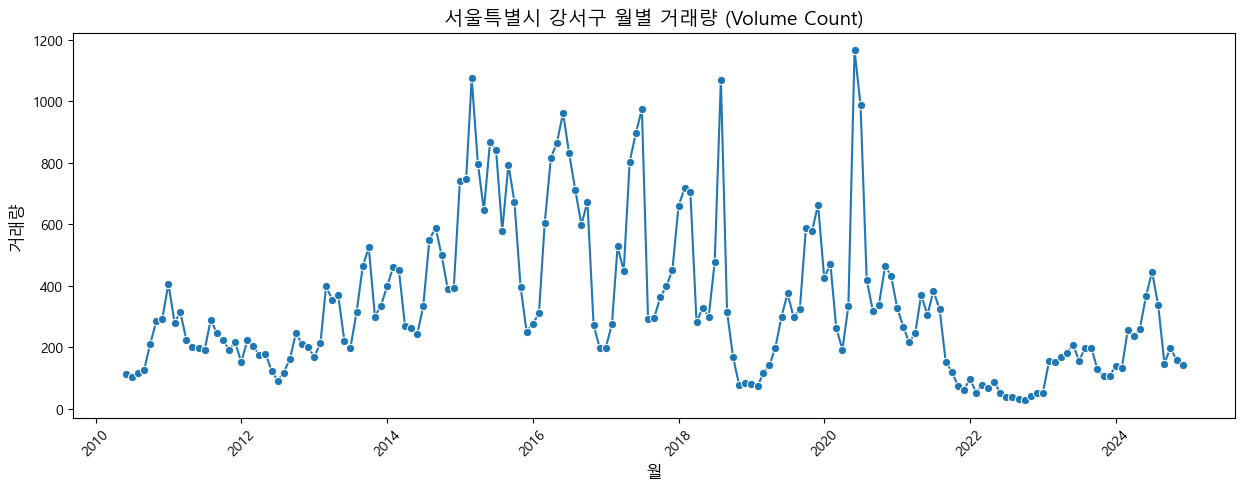

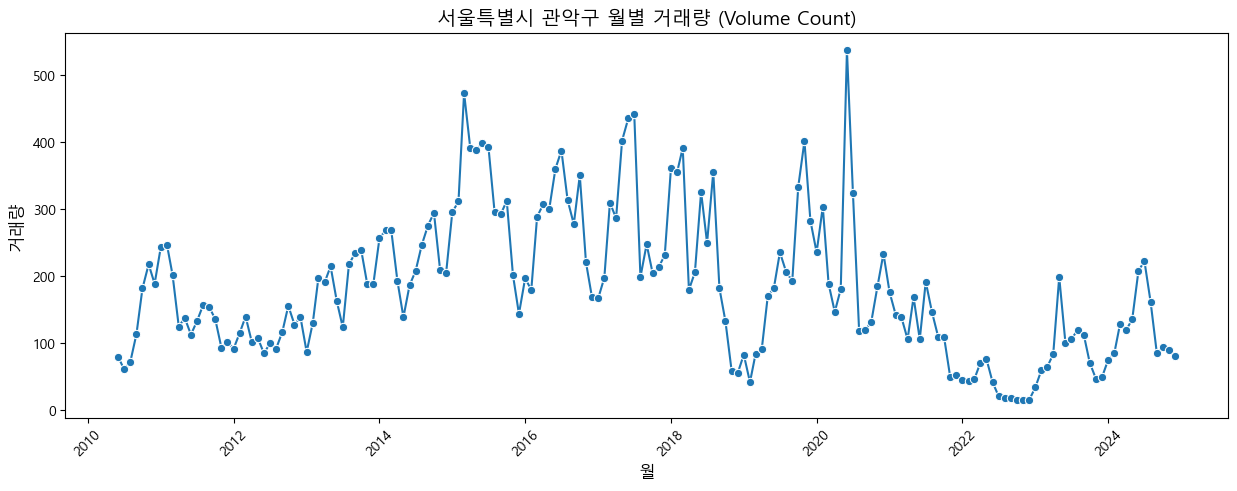

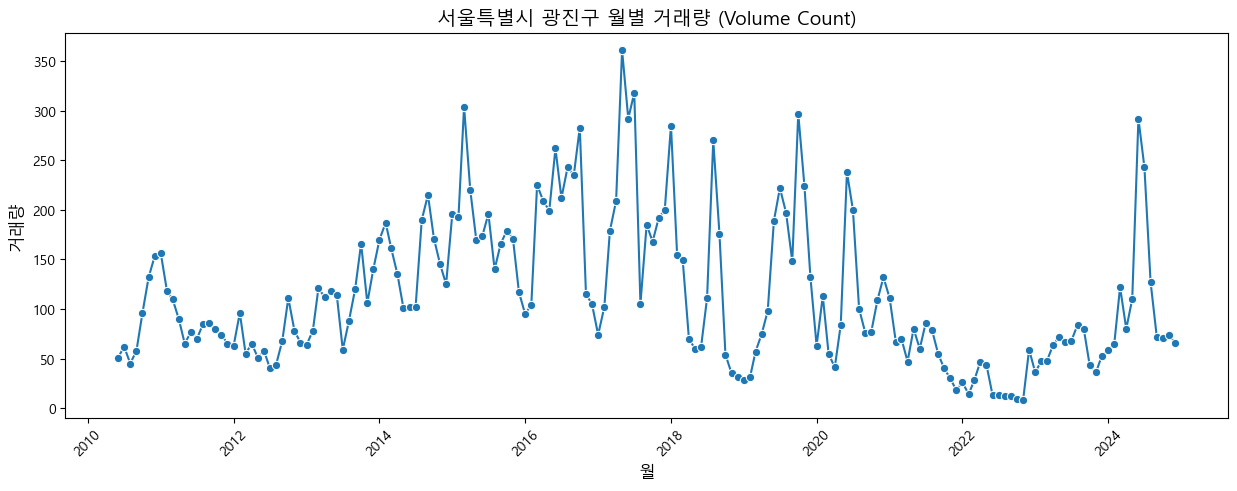

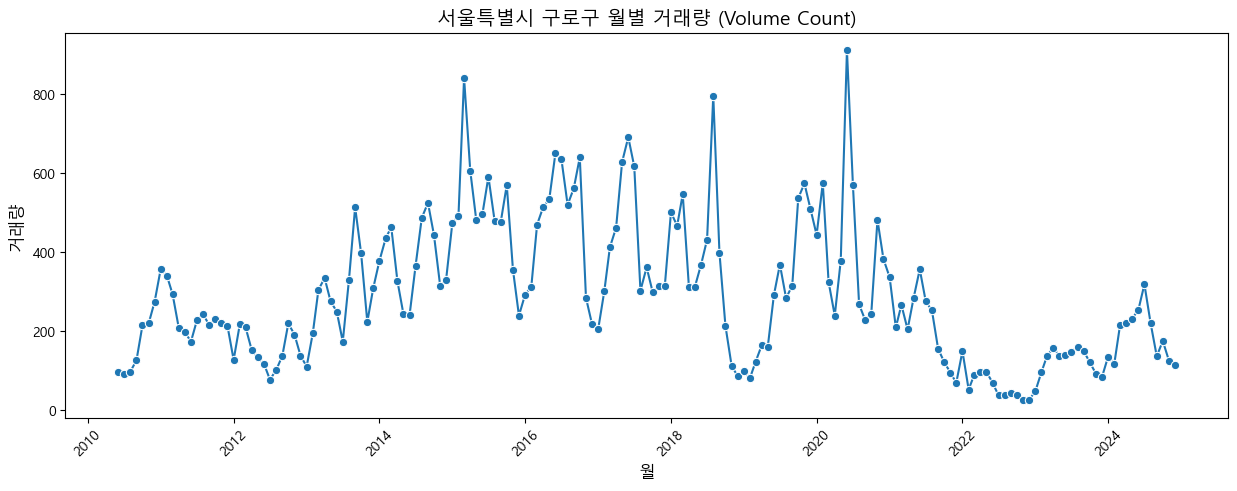

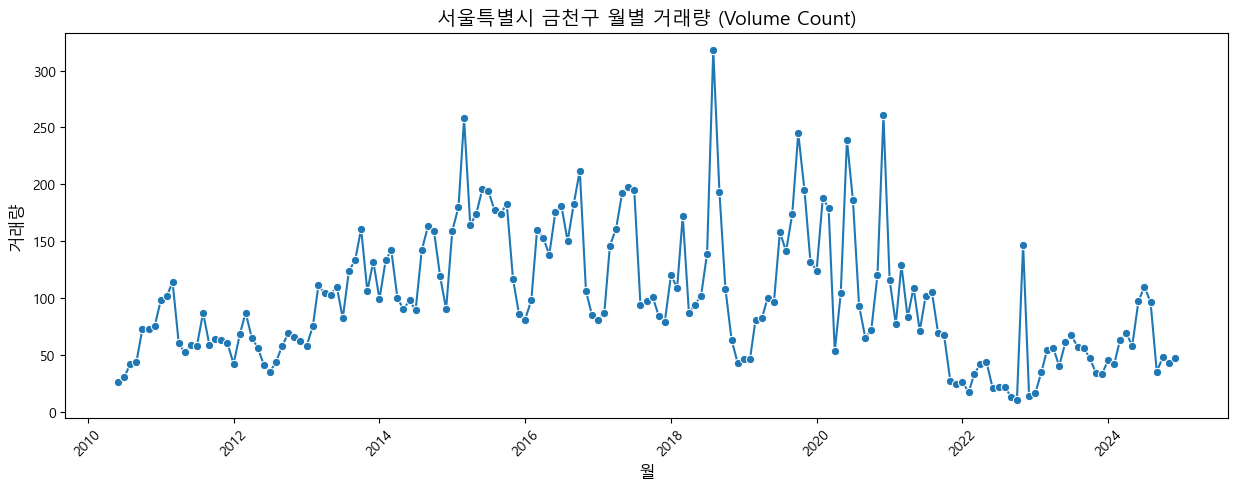

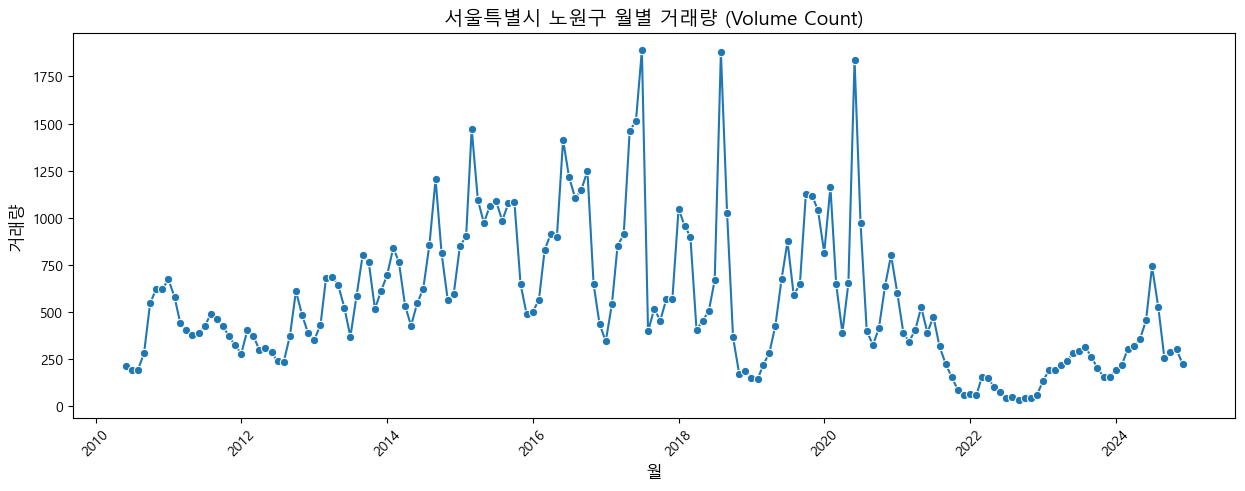

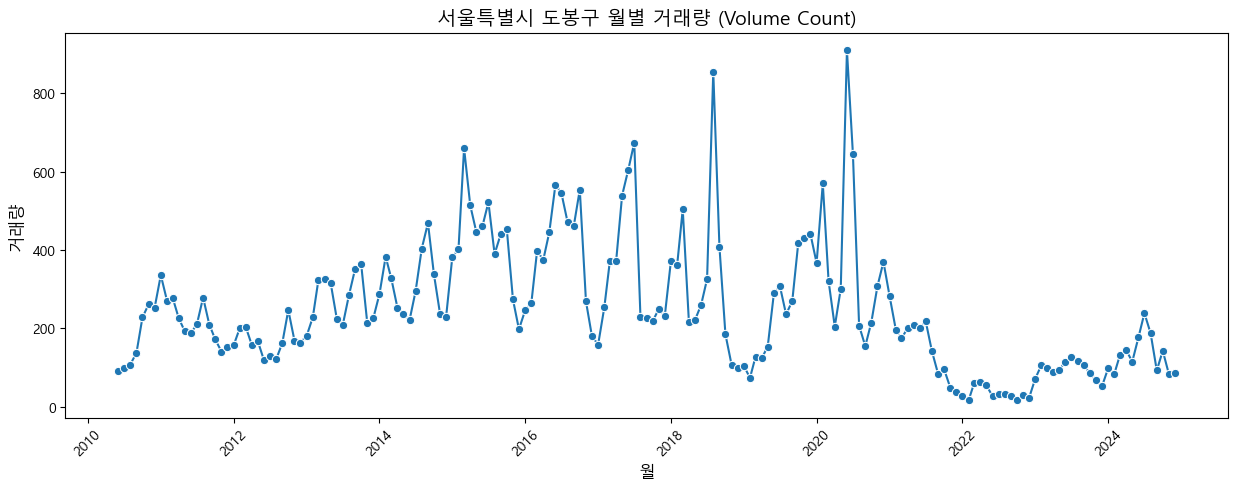

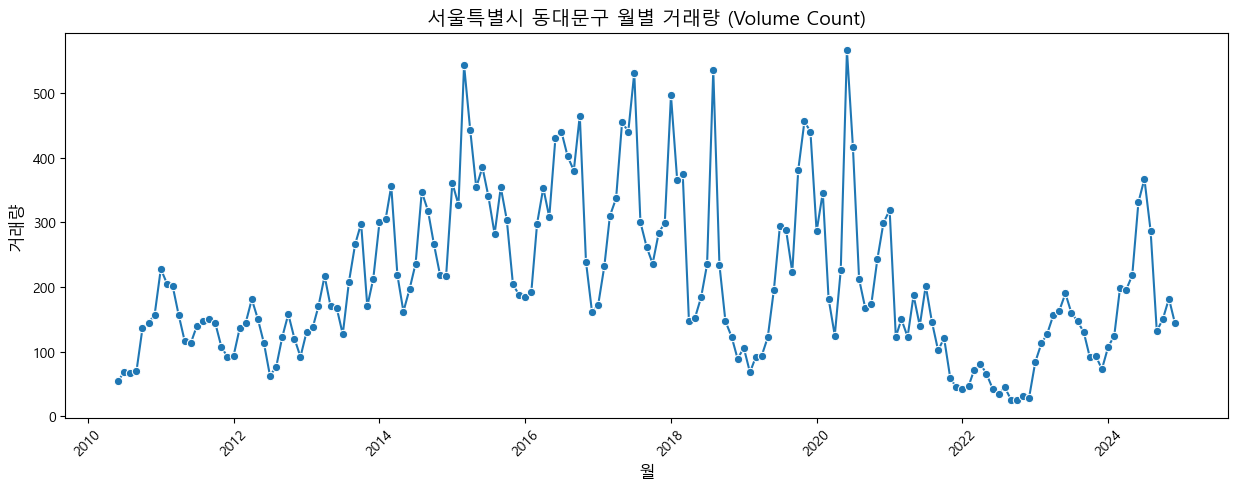

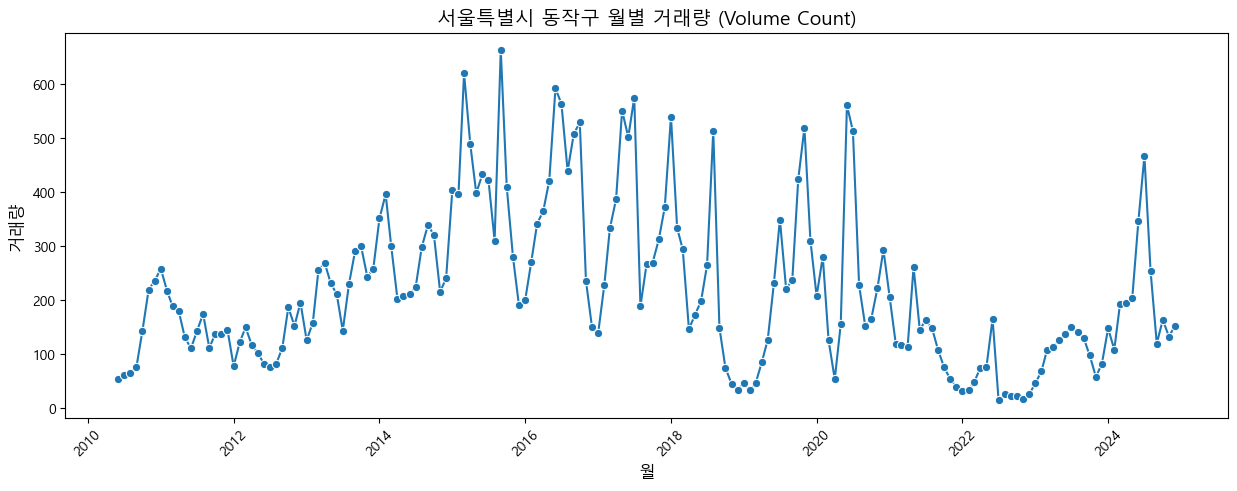

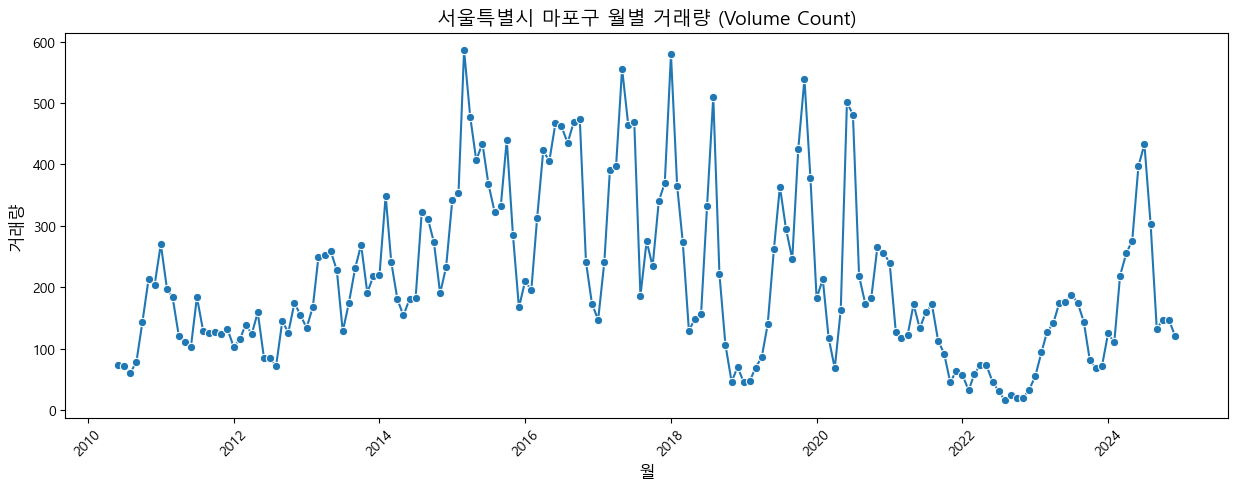

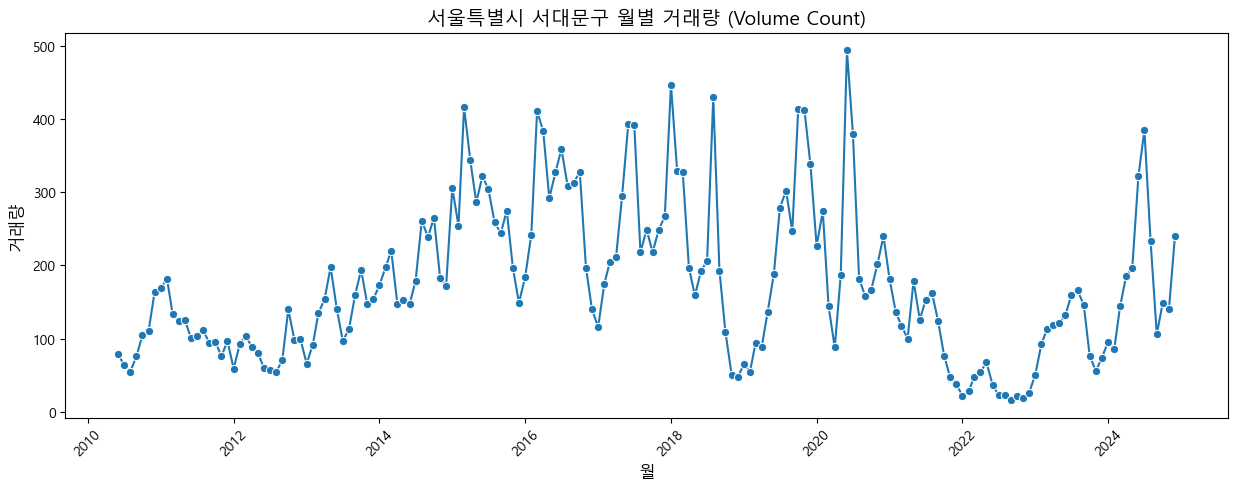

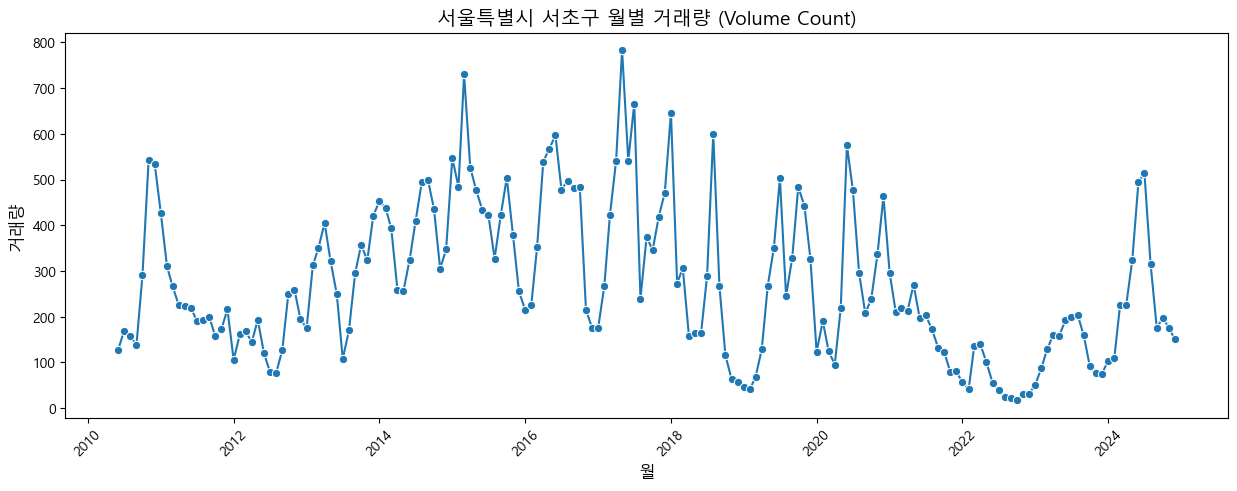

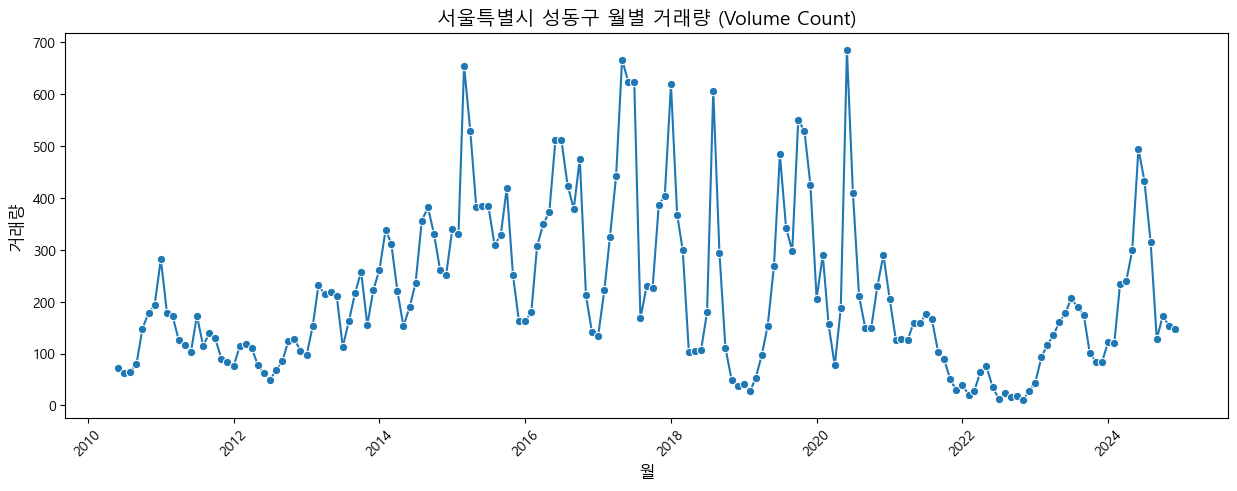

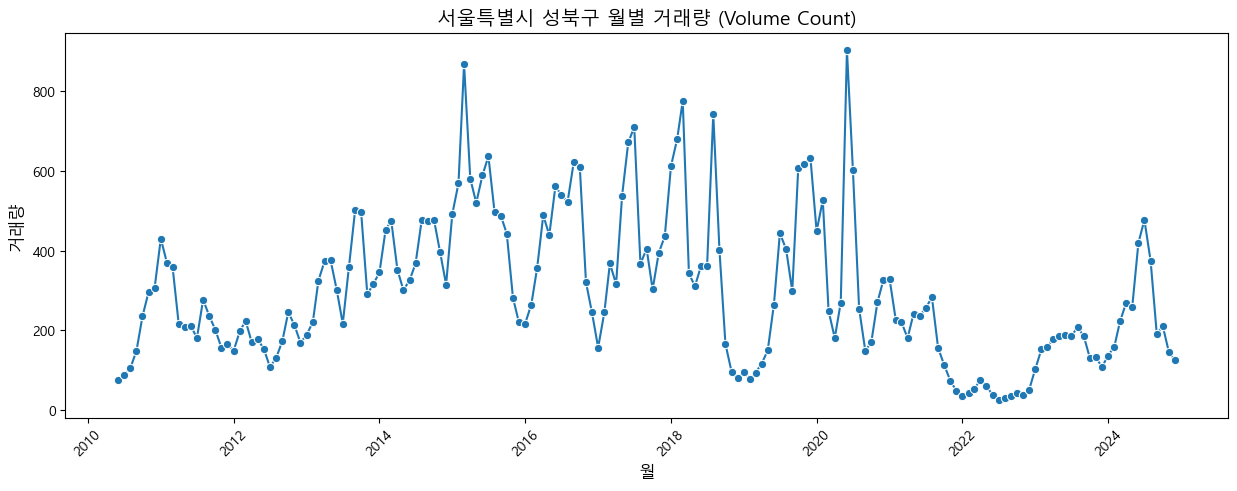

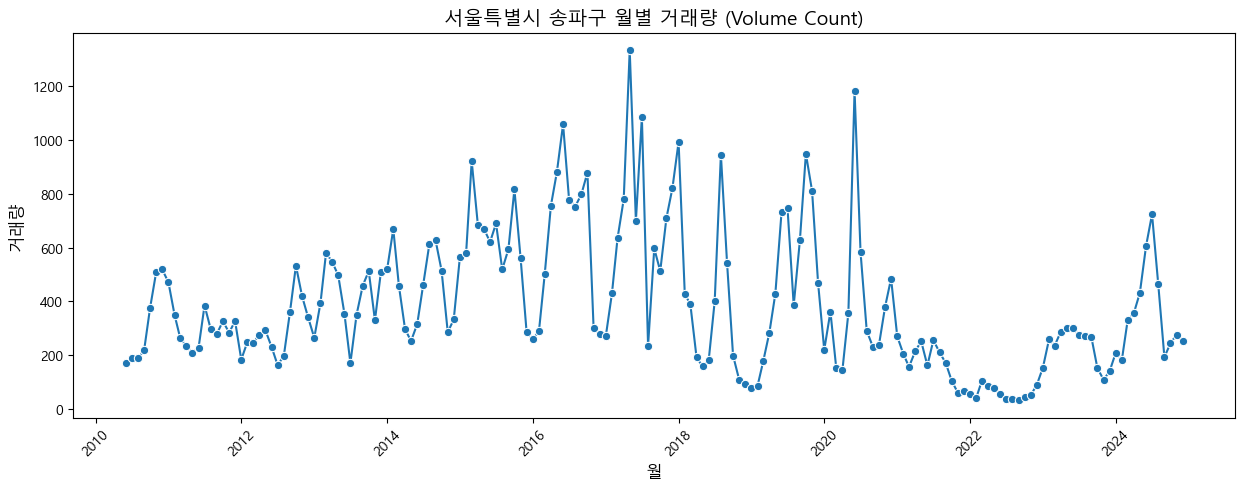

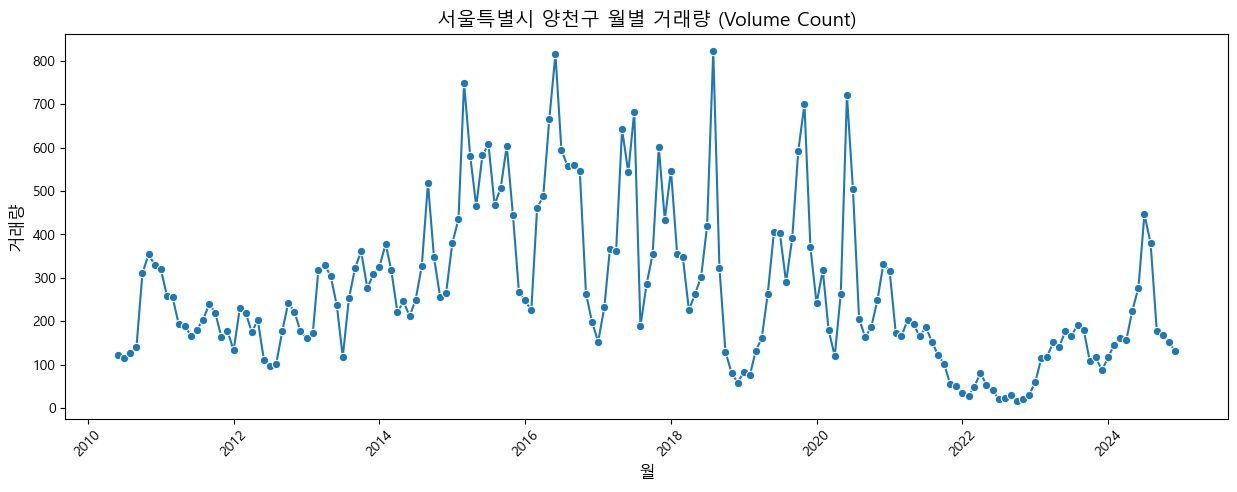

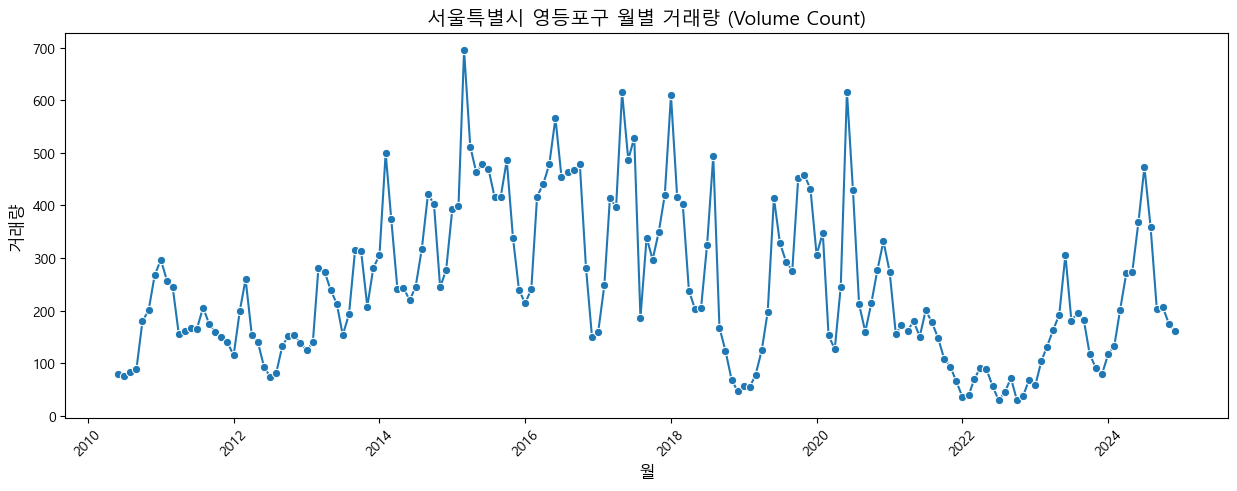

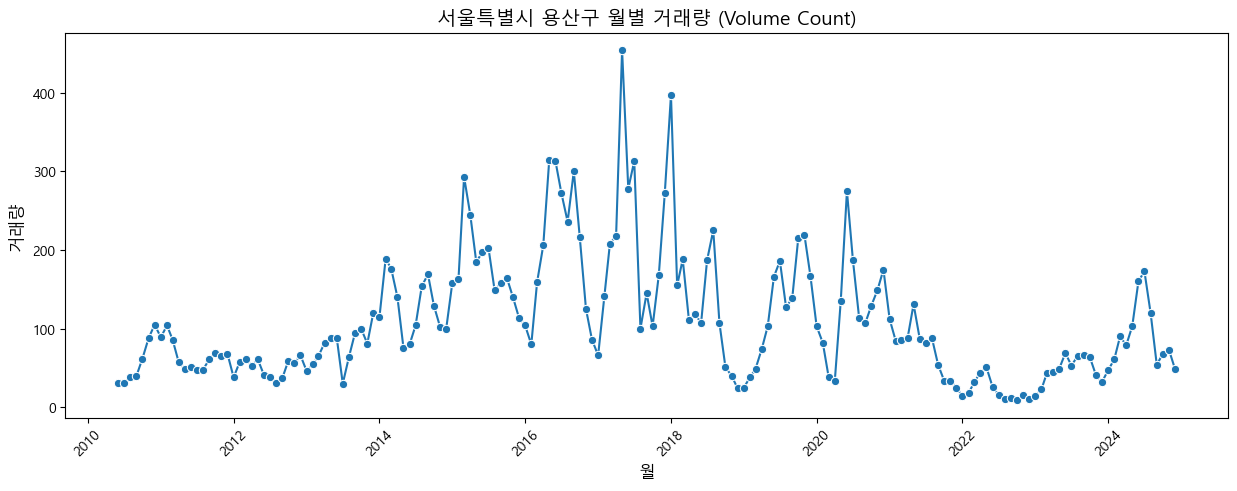

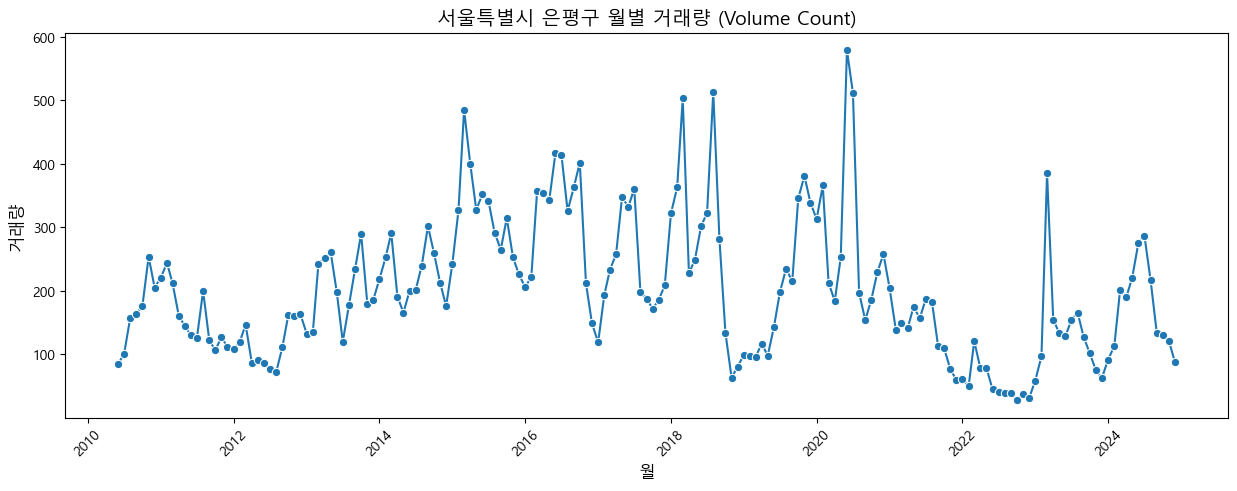

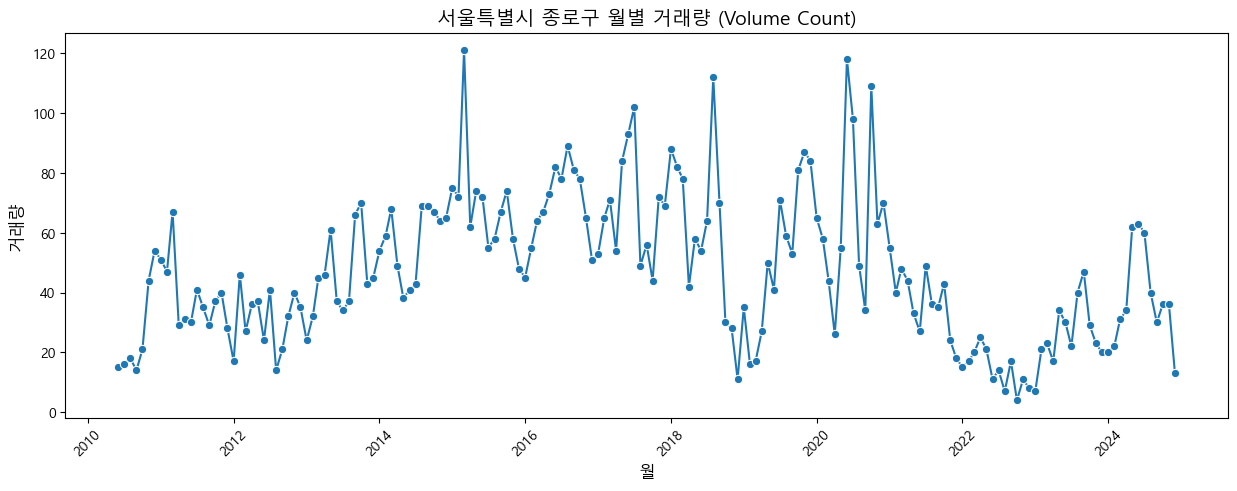

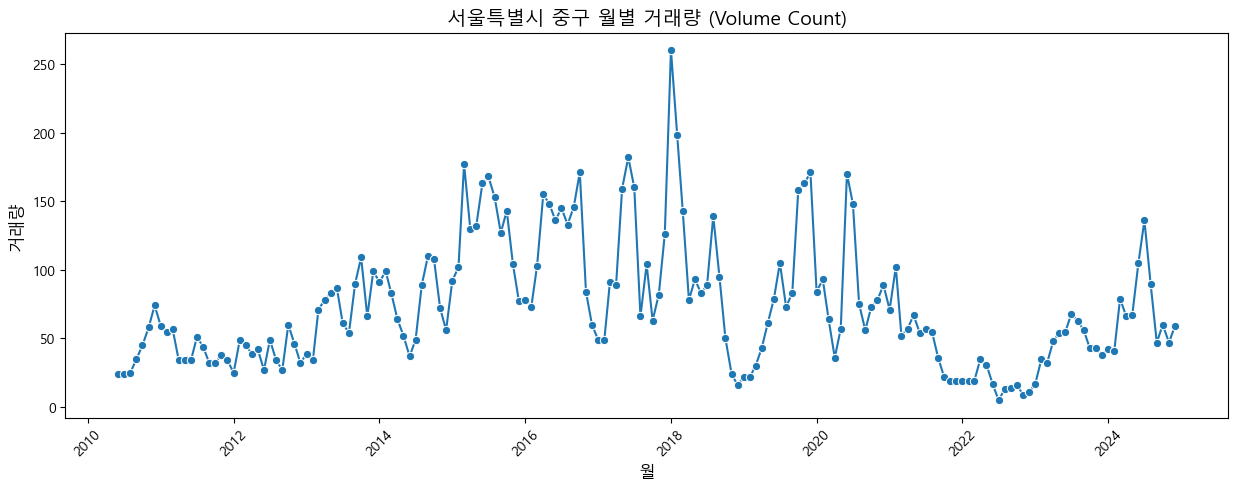

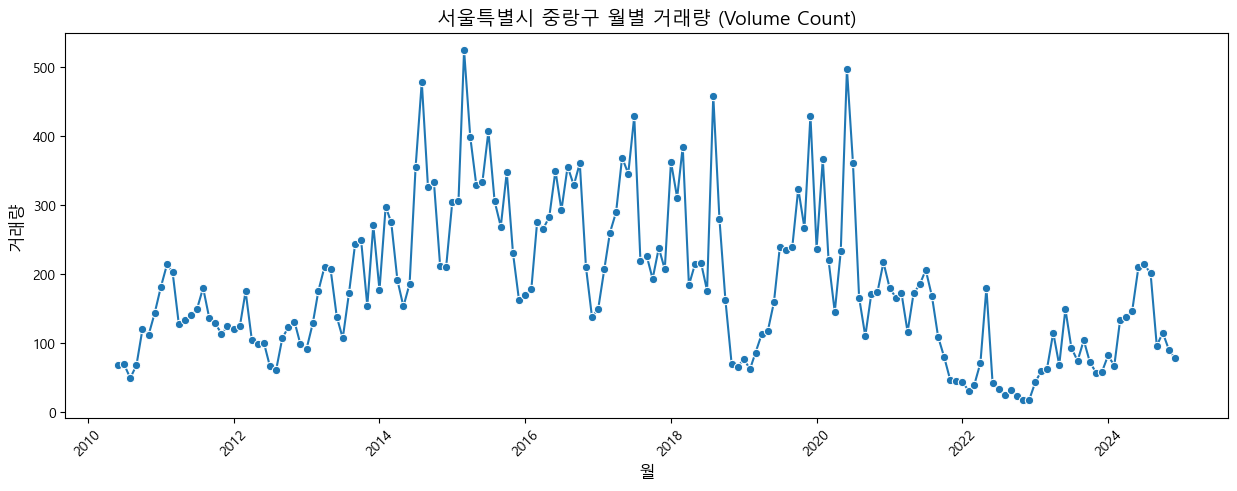

In [13]:
# 행정구별 개별 플롯을 생성하여 표시
for region in monthly_apt_volume_df['region'].unique():
    region_df = monthly_apt_volume_df[monthly_apt_volume_df['region'] == region]

    plt.figure(figsize=(15, 5))
    sns.lineplot(data=region_df, x='date', y='volume_cnt', marker='o')

    plt.title(f"{region} 월별 거래량 (Volume Count)", fontsize=14)
    plt.xlabel("월", fontsize=12)
    plt.ylabel("거래량", fontsize=12)
    plt.xticks(rotation=45)

    plt.show()

## 3.2 행정구 / 월 단위 평균 매매 거래가 시각화

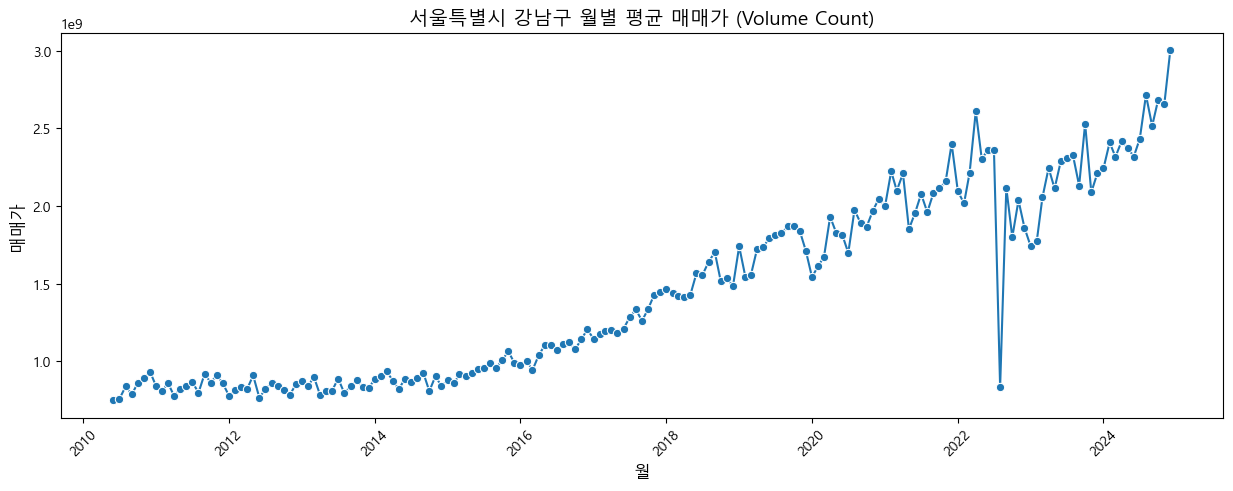

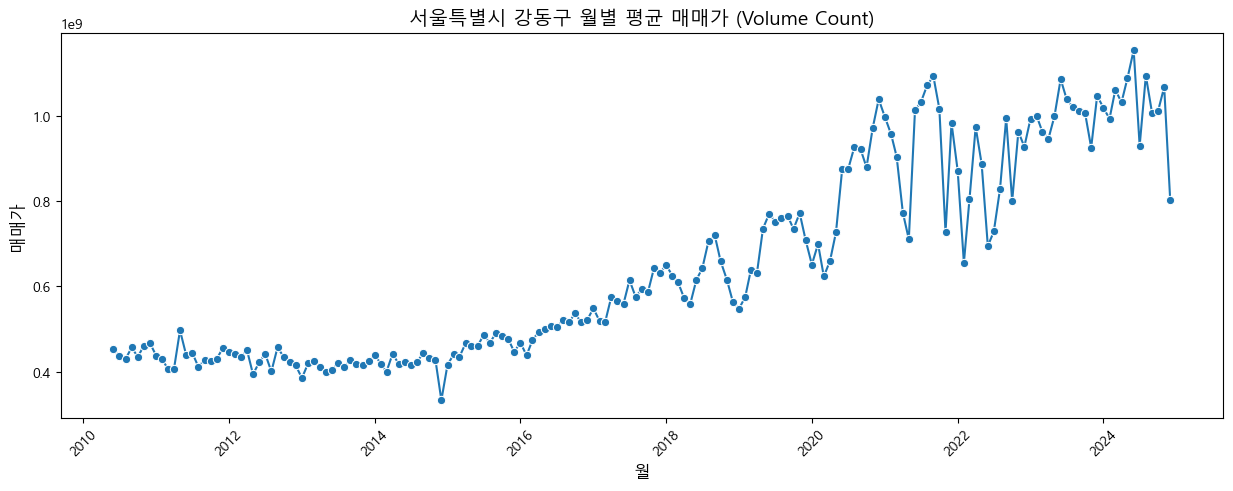

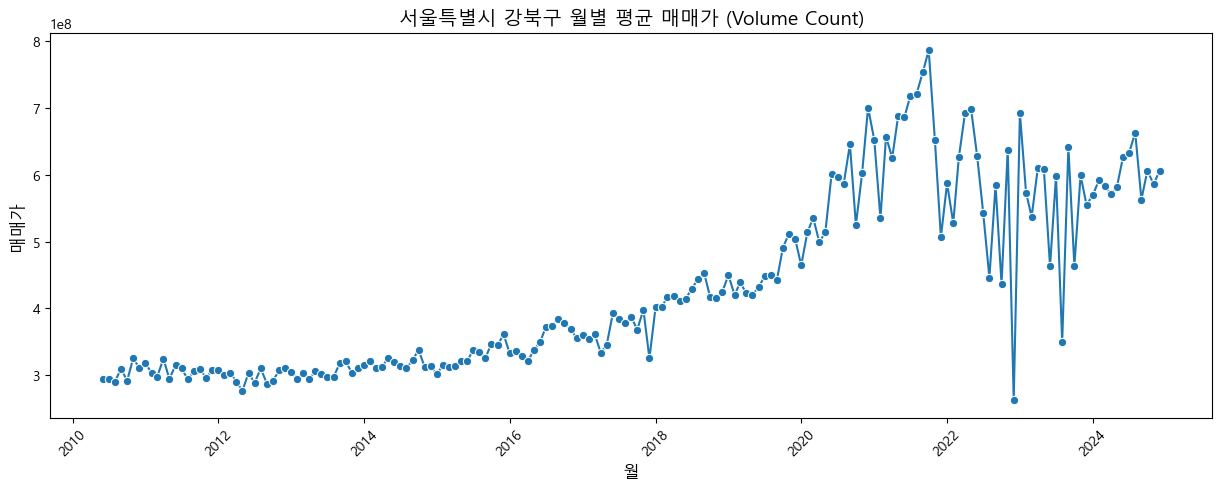

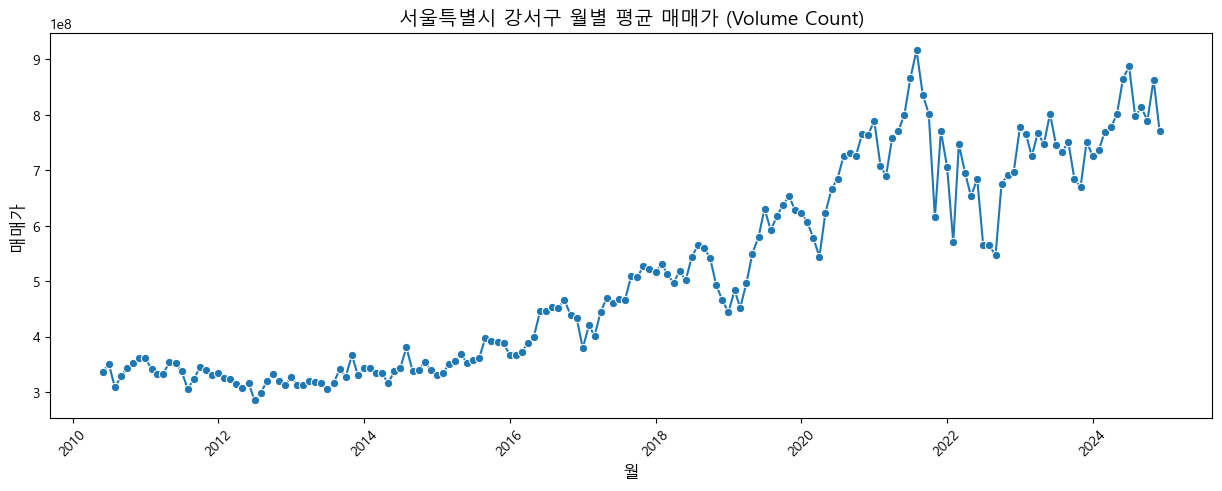

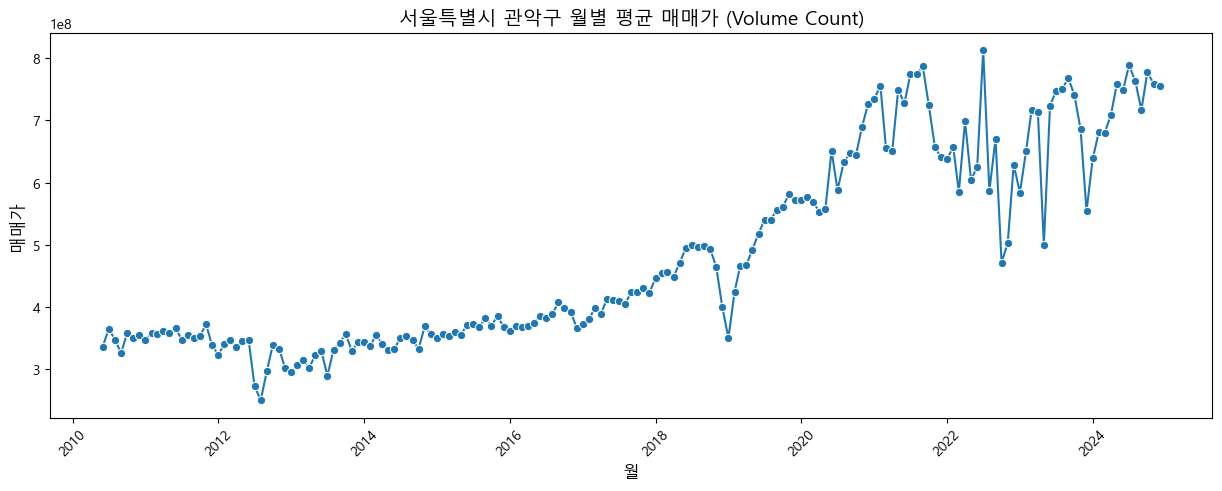

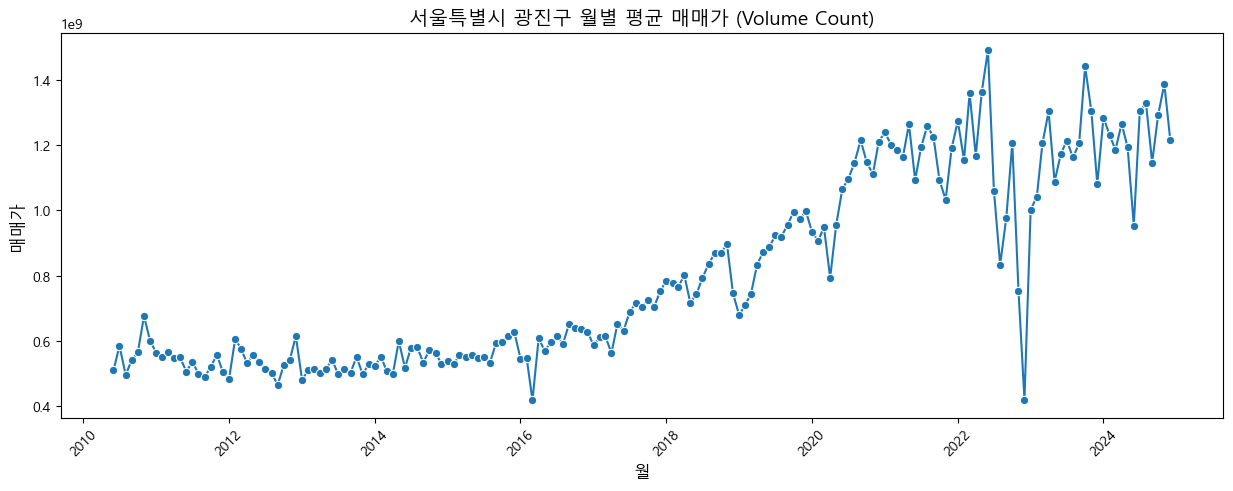

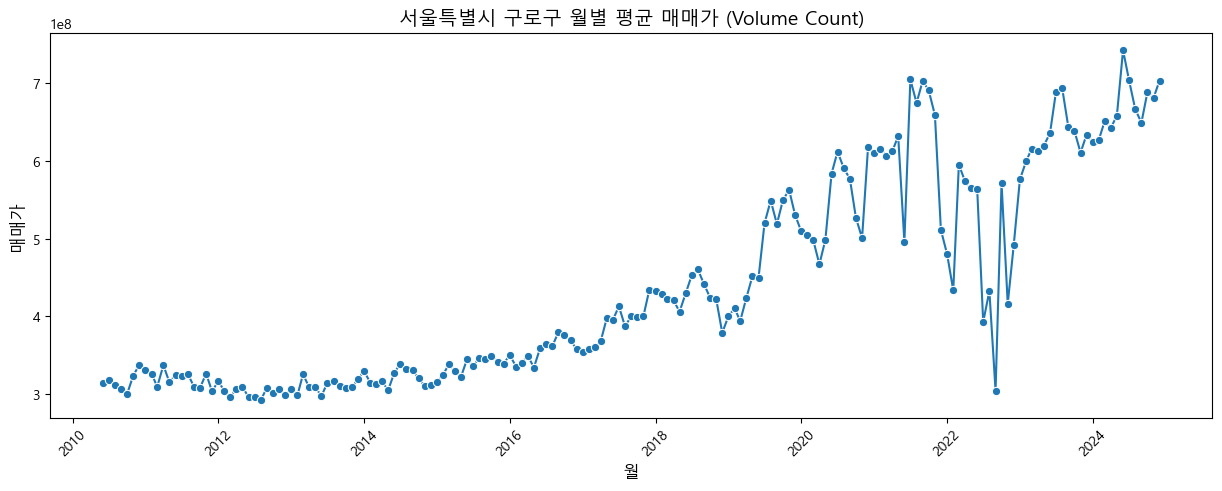

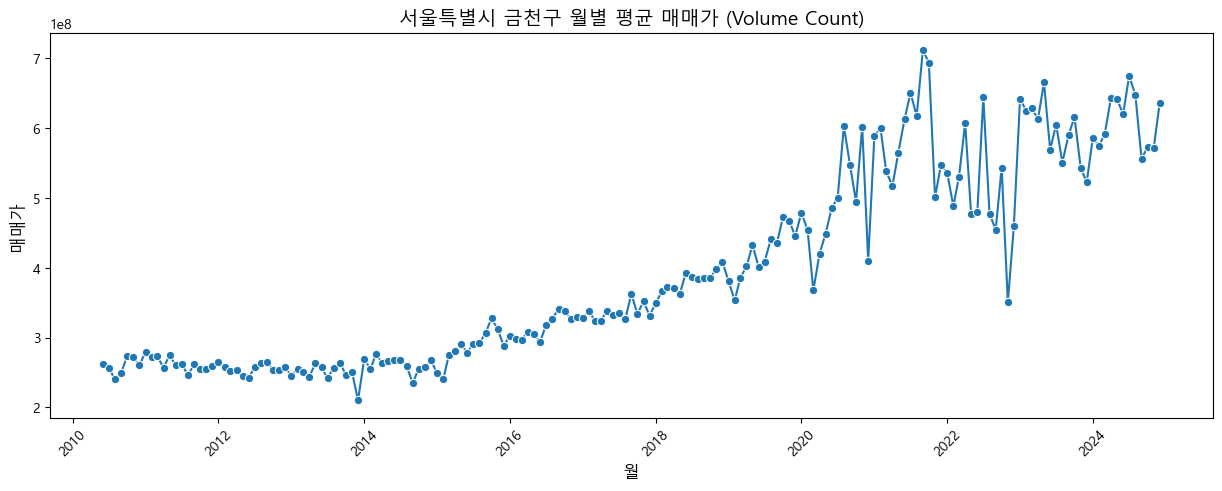

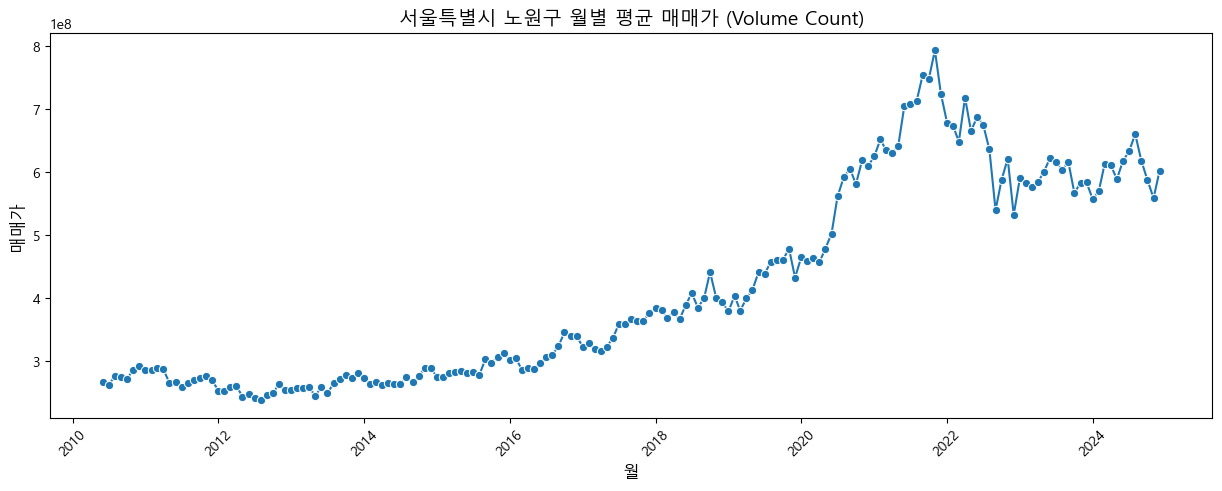

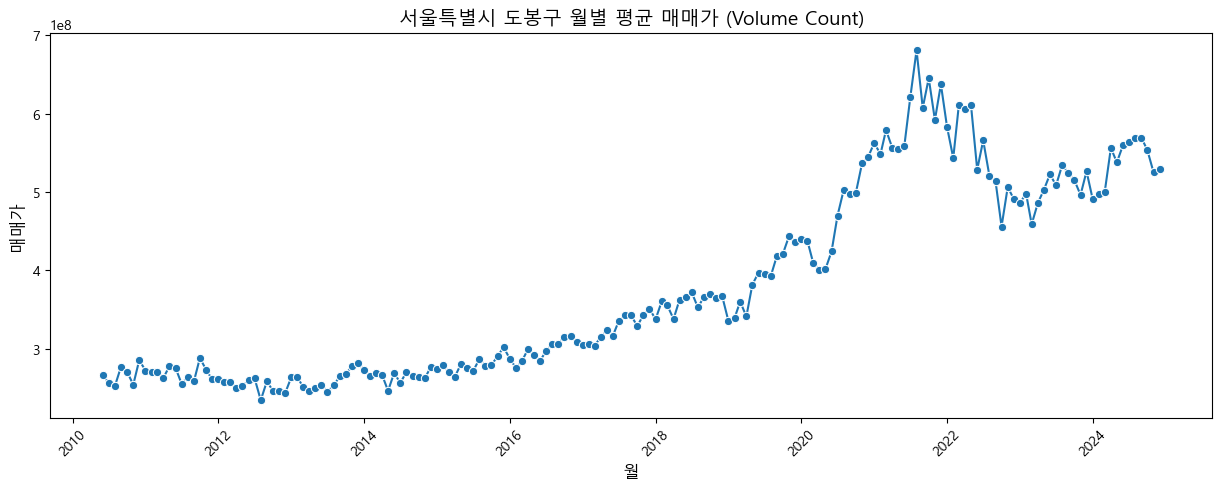

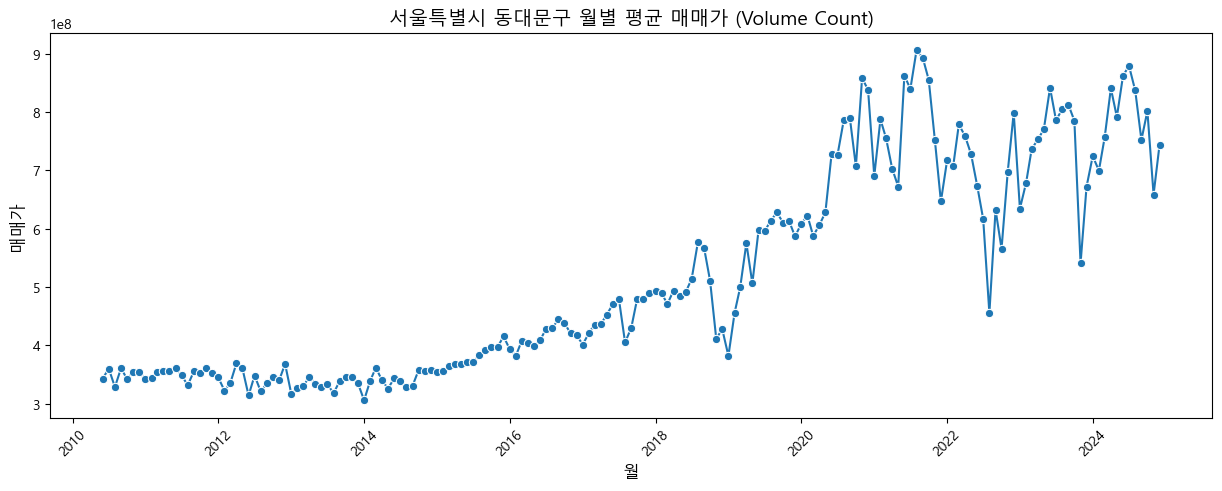

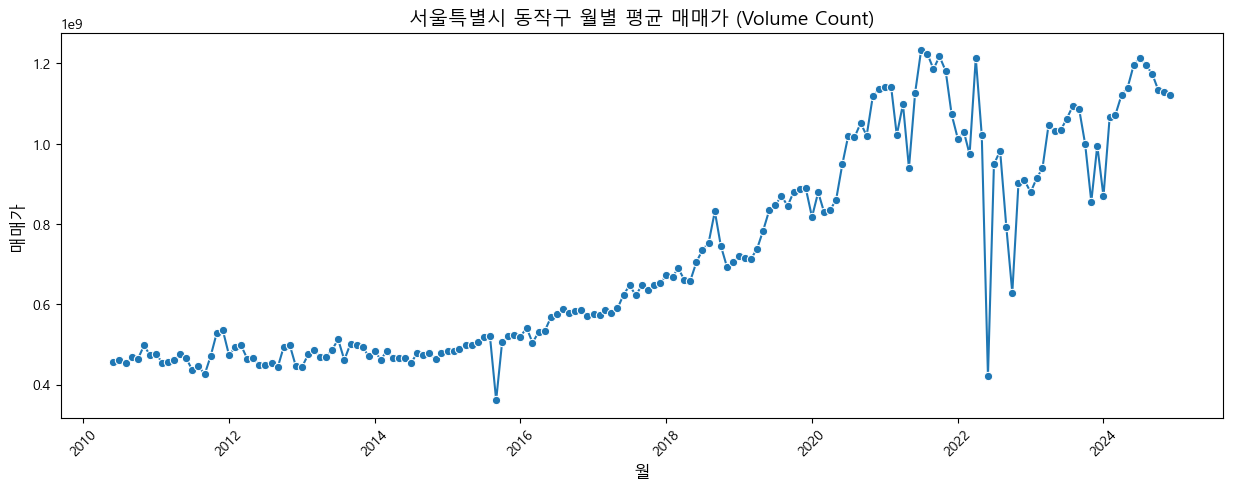

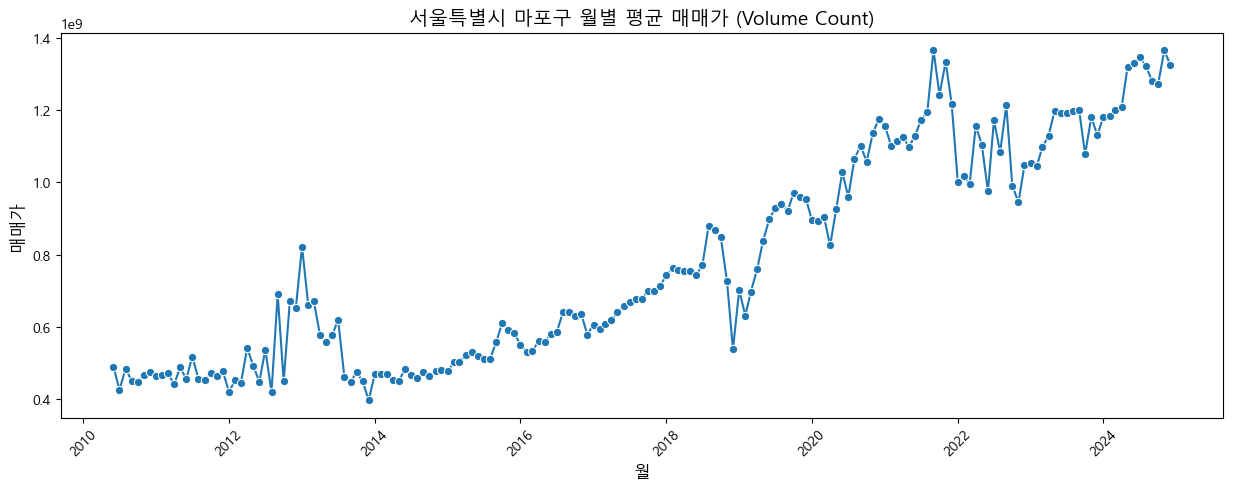

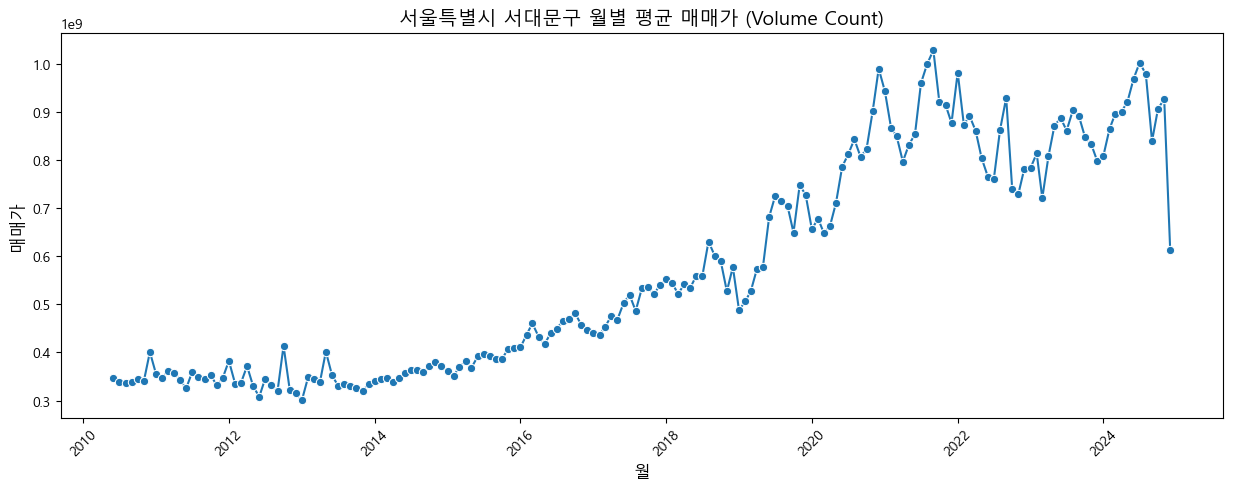

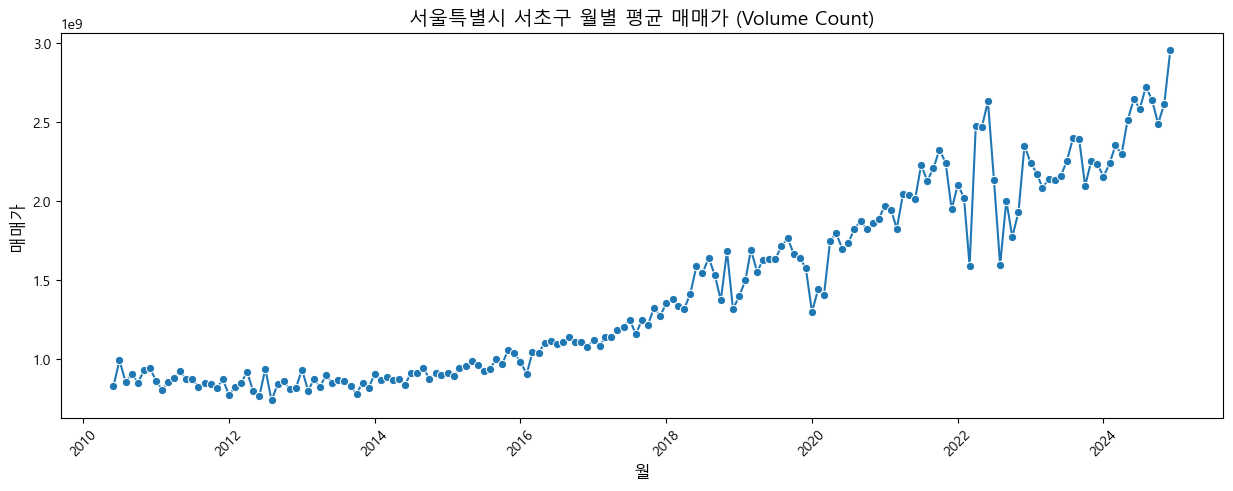

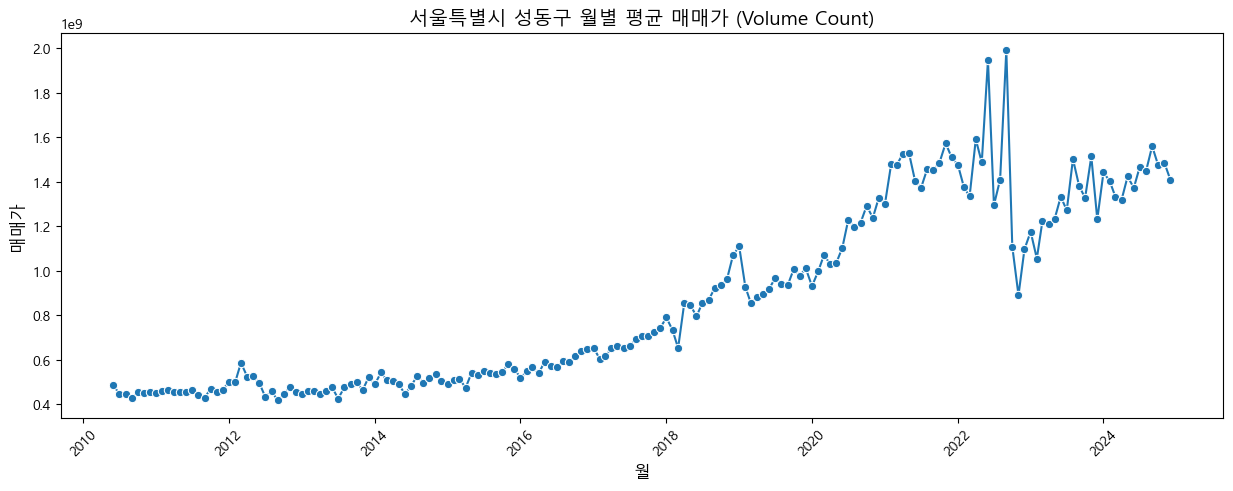

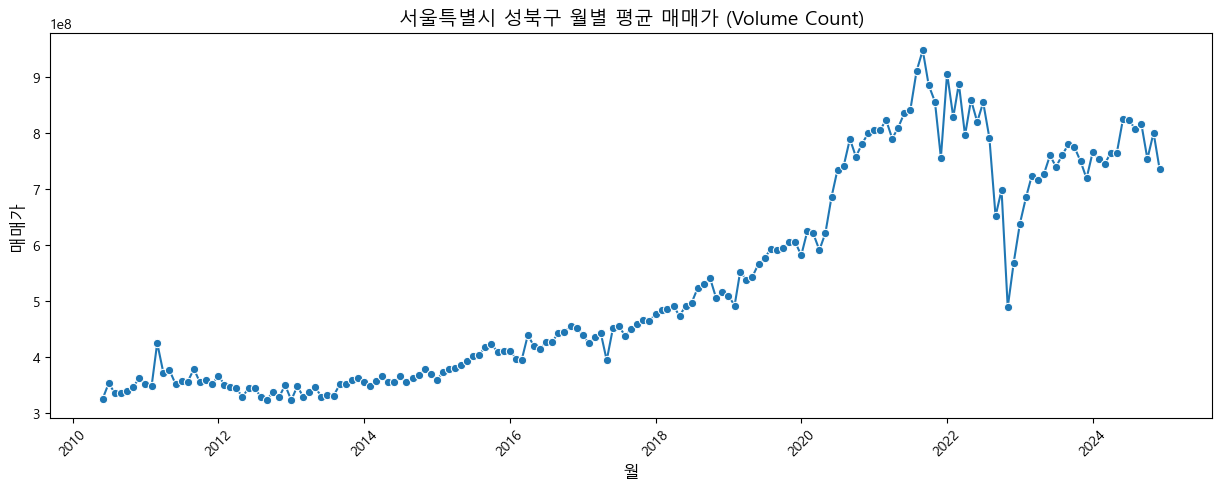

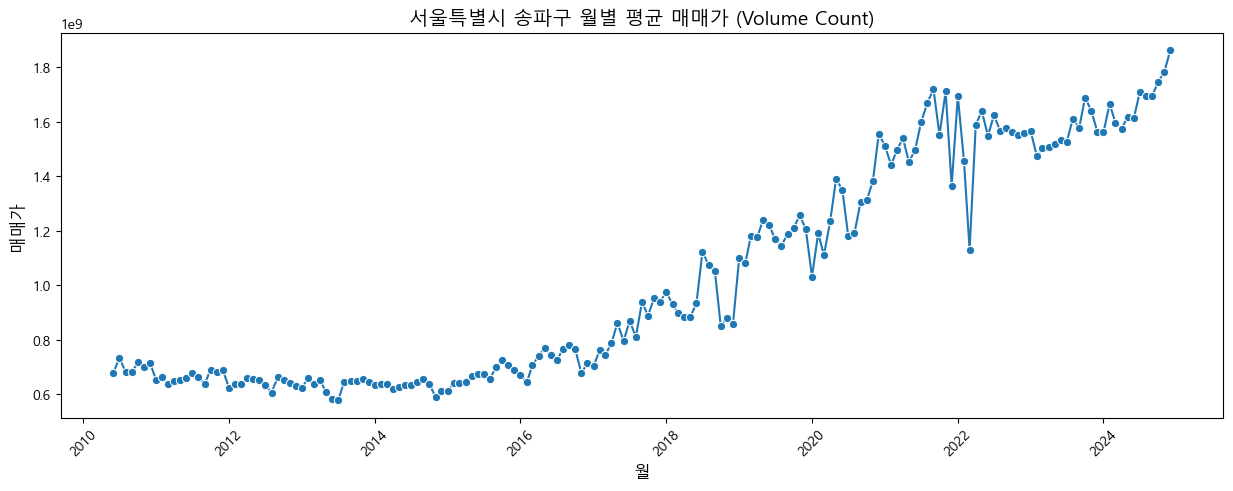

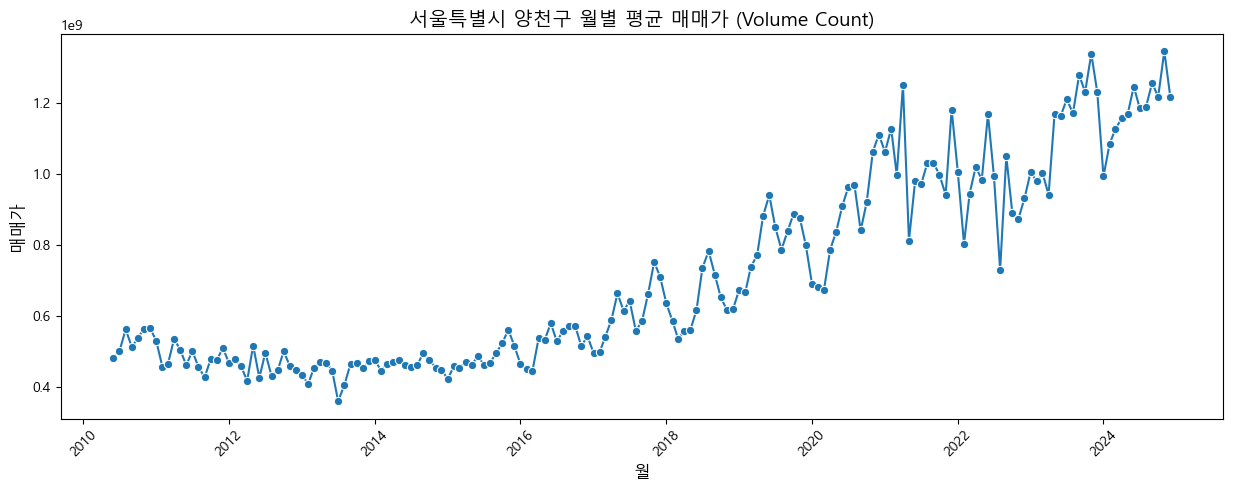

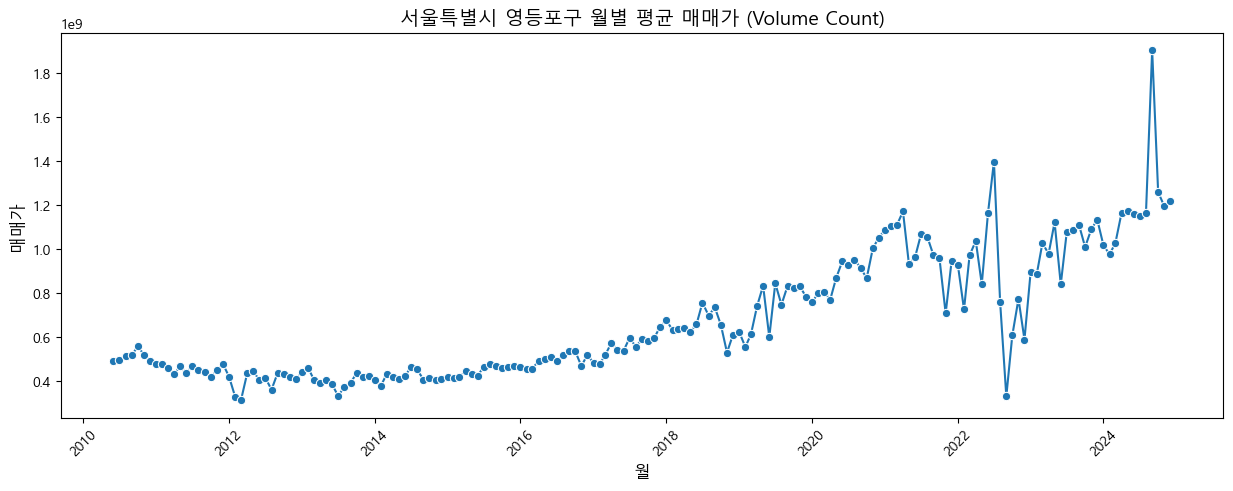

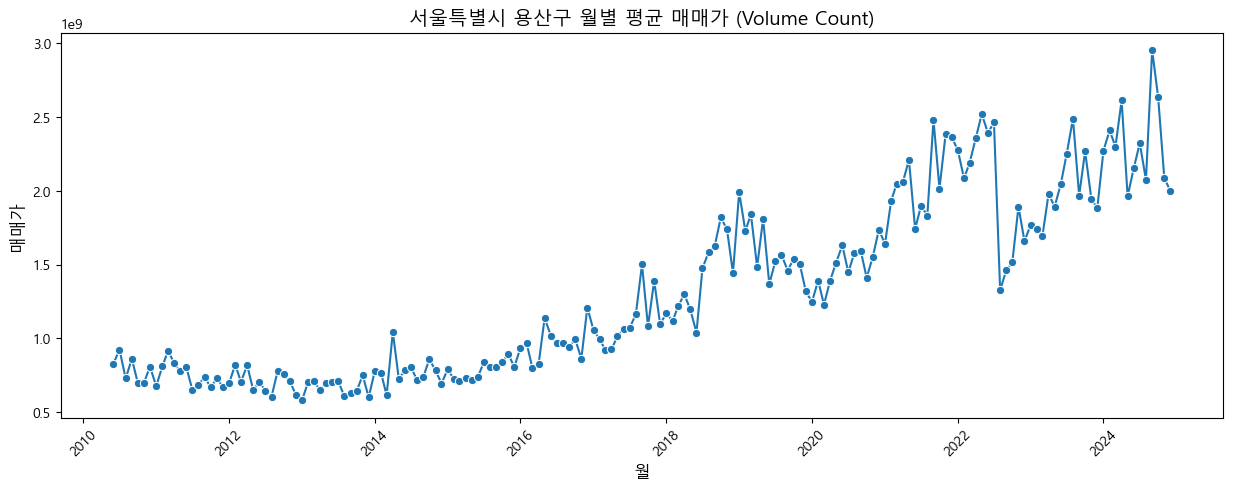

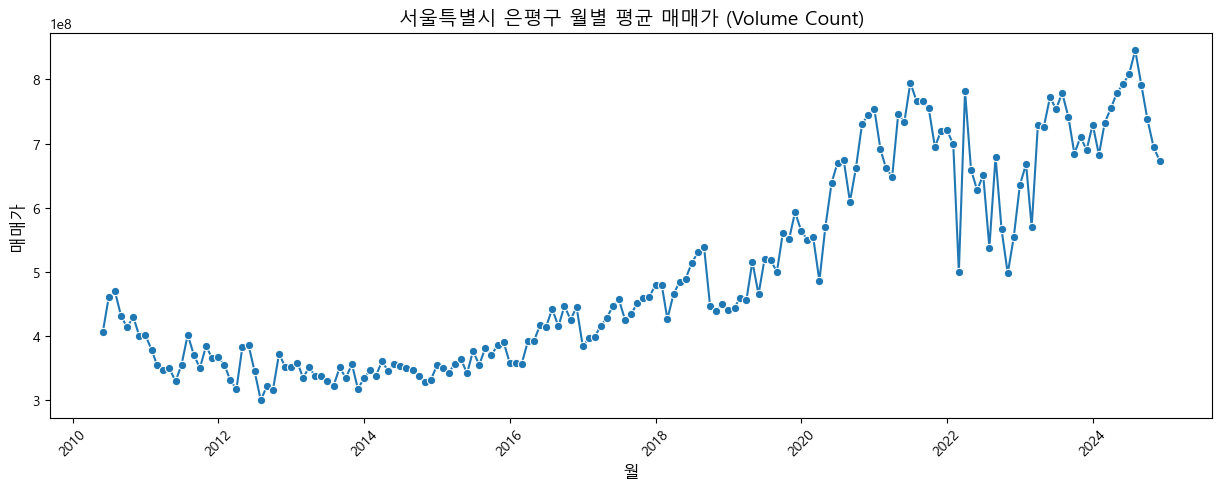

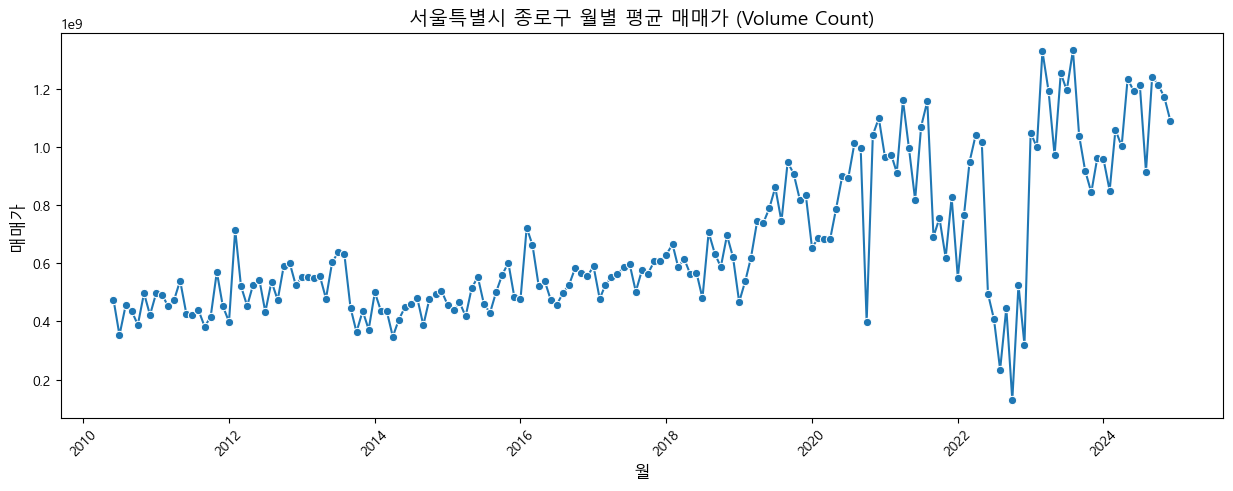

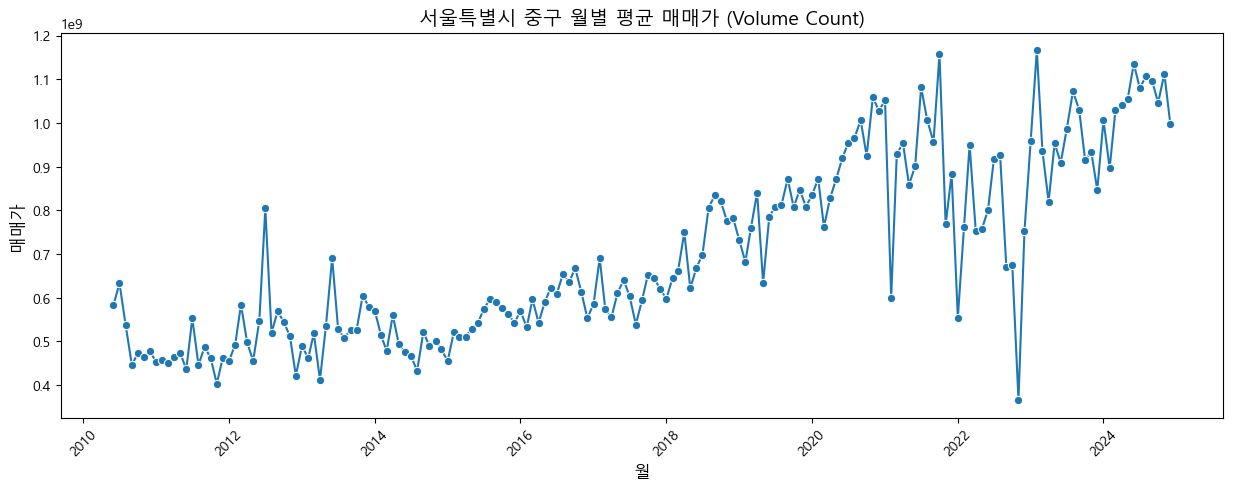

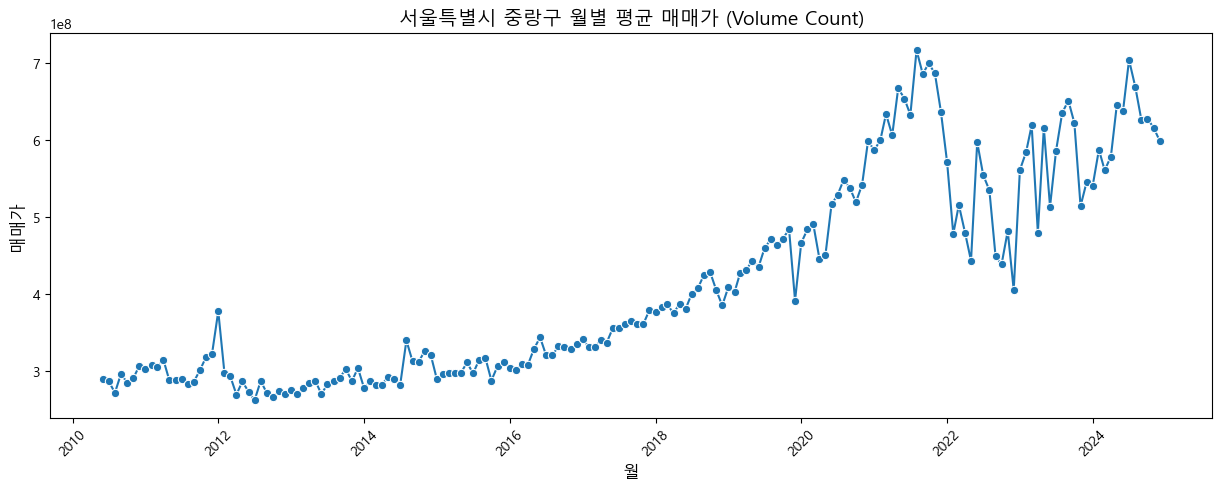

In [15]:
# 행정구별 개별 플롯을 생성하여 표시
for region in monthly_apt_volume_df['region'].unique():
    region_df = monthly_apt_volume_df[monthly_apt_volume_df['region'] == region]

    plt.figure(figsize=(15, 5))
    sns.lineplot(data=region_df, x='date', y='avg_sales', marker='o')

    plt.title(f"{region} 월별 평균 매매가 (Volume Count)", fontsize=14)
    plt.xlabel("월", fontsize=12)
    plt.ylabel("매매가", fontsize=12)
    plt.xticks(rotation=45)

    plt.show()